# Altitude de um Foguete — Filtro de Kalman com Entrada de Controle

Este notebook aplica o **Filtro de Kalman com entrada de controle** para estimar a altitude
e velocidade vertical de um foguete, utilizando dados de um altímetro e um acelerômetro.

Diferente dos exemplos anteriores, aqui o sistema possui uma **entrada de controle** $u$: a
aceleração de propulsão medida pelo acelerômetro. O altímetro fornece as medições $z$, enquanto
o acelerômetro alimenta o modelo de previsão.

**Referência:** [Kalman Filter — Example 10](https://kalmanfilter.net/PT/default_pt.aspx)

## 1. Imports

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Carregamento dos Dados

| Coluna | Descrição |
|---|---|
| `n` | Número do passo de tempo (1 a 30) |
| `alt_verdadeira_m` | Altitude verdadeira [m] |
| `vel_verdadeira_ms` | Velocidade vertical verdadeira [m/s] |
| `medicao_altimetro_m` | Medição ruidosa do altímetro [m] ($\sigma = 20$ m) |
| `medicao_acelerometro_ms2` | Medição ruidosa do acelerômetro [m/s²] ($\varepsilon = 0.1$ m/s²) |

In [4]:
RAIZ = Path().resolve().parent.parent
CAMINHO = RAIZ / "arquivos" / "exemploC_foguete.csv"

df = pd.read_csv(CAMINHO)
df.head(10)

,n,alt_verdadeira_m,vel_verdadeira_ms,medicao_altimetro_m,medicao_acelerometro_ms2
0,1,0.938,7.5,12.698,20.0043
1,2,3.750,15.0,-32.355,20.0718
2,3,8.438,22.5,10.783,20.4033
3,4,15.000,30.0,7.353,20.2251
4,5,23.438,37.5,2.175,20.0953
5,6,33.750,45.0,-5.395,20.1972
6,7,45.938,52.5,64.882,20.1643
7,8,60.000,60.0,87.929,20.2198
8,9,75.938,67.5,75.209,20.2517
9,10,93.750,75.0,103.498,20.3148


## 3. Espaço de Estados

O vetor de estados tem 2 componentes — altitude e velocidade vertical:

$$\mathbf{x} = \begin{bmatrix} p \\ v \end{bmatrix}$$

### Dinâmica com entrada de controle

A física $\dot{p} = v$, $\dot{v} = u$ (aceleração de propulsão) dá:

$$\mathbf{A} = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}, \quad \mathbf{B} = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

### Discretização ($\Delta t = 0.25$ s)

Como $\mathbf{A}^2 = 0$ (nilpotente), a série exata resulta em:

$$\mathbf{F} = \mathbf{I} + \mathbf{A}\,\Delta t = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}$$

$$\mathbf{G} = \left(\mathbf{I}\,\Delta t + \mathbf{A}\,\frac{\Delta t^2}{2}\right) \mathbf{B} = \begin{bmatrix} \frac{\Delta t^2}{2} \\ \Delta t \end{bmatrix} = \begin{bmatrix} 0.03125 \\ 0.25 \end{bmatrix}$$

### Matriz de observação $\mathbf{H}$ e covariância $\mathbf{R}$

O altímetro mede apenas a altitude:

$$\mathbf{H} = \begin{bmatrix} 1 & 0 \end{bmatrix}, \quad R = \sigma_m^2 = 400 \quad (\sigma_m = 20 \text{ m})$$

### Covariância de processo $\mathbf{Q}$

A incerteza vem do erro do acelerômetro $\varepsilon = 0.1$ m/s²:

$$\mathbf{Q} = \varepsilon^2 \begin{bmatrix} \frac{\Delta t^4}{4} & \frac{\Delta t^3}{2} \\ \frac{\Delta t^3}{2} & \Delta t^2 \end{bmatrix}$$

### Entrada de controle

O acelerômetro mede $a_m = \ddot{x} - g + \varepsilon$. Para recuperar a aceleração real, somamos $g$:

$$u_n = a_m + g \quad (g = 9.8 \text{ m/s}^2)$$

## 4. Parâmetros do Filtro

In [5]:
# Constantes físicas
dt = 0.25   # intervalo de amostragem [s]
g = 9.8     # aceleração da gravidade [m/s²]
eps = 0.1   # erro do acelerômetro [m/s²]

# --- Matriz de transição de estados (2×2) ---
F = np.array([[1, dt],
              [0, 1]])

# --- Vetor de controle (2×1) ---
G = np.array([0.5 * dt**2, dt])

# --- Matriz de observação (1×2) ---
H = np.array([[1, 0]])

# --- Covariância de medição (1×1) ---
sigma_m = 20.0
R = np.array([[sigma_m**2]])

# --- Covariância de processo (2×2) ---
Q = eps**2 * np.array([[dt**4 / 4, dt**3 / 2],
                       [dt**3 / 2, dt**2]])

# --- Estado inicial e covariância ---
x = np.zeros(2)  # [altitude, velocidade]
P = 500.0 * np.eye(2)

# Matriz identidade (2×2)
I2 = np.eye(2)

print("F =")
print(F)
print(f"\nG = {G}")
print(f"\nH = {H}")
print(f"\nR = {R}")
print("\nQ =")
print(Q)

F =
[[1.   0.25]
 [0.   1.  ]]

G = [0.03125 0.25   ]

H = [[1 0]]

R = [[400.]]

Q =
[[9.765625e-06 7.812500e-05]
 [7.812500e-05 6.250000e-04]]


### Tabela de Parâmetros

| Parâmetro | Valor | Significado |
|---|---|---|
| $\Delta t$ | 0.25 s | Intervalo entre amostras |
| $g$ | 9.8 m/s² | Aceleração da gravidade |
| $\varepsilon$ | 0.1 m/s² | Erro do acelerômetro |
| $\mathbf{F}$ | $\begin{bmatrix} 1 & 0.25 \\ 0 & 1 \end{bmatrix}$ | Transição de estados |
| $\mathbf{G}$ | $[0.03125, 0.25]^T$ | Entrada de controle |
| $\mathbf{H}$ | $\begin{bmatrix} 1 & 0 \end{bmatrix}$ | Observação (mede altitude) |
| $R$ | 400 | Variância do ruído de altímetro [m²] |
| $\mathbf{x}_0$ | $[0, 0]^T$ | Estado inicial |
| $\mathbf{P}_0$ | $\text{diag}(500, 500)$ | Covariância inicial (alta incerteza) |

## 5. Execução do Filtro de Kalman

Para cada passo $k$, temos a medição $z_k$ (altímetro) e a entrada $u_k$ (acelerômetro + gravidade):

### Previsão (com controle!)
$$\hat{\mathbf{x}}_k^- = \mathbf{F}\,\hat{\mathbf{x}}_{k-1}^+ + \mathbf{G}\,u_k$$
$$\mathbf{P}_k^- = \mathbf{F}\,\mathbf{P}_{k-1}^+\,\mathbf{F}^T + \mathbf{Q}$$

### Atualização
$$\mathbf{K}_k = \mathbf{P}_k^-\,\mathbf{H}^T\left(\mathbf{H}\,\mathbf{P}_k^-\,\mathbf{H}^T + R\right)^{-1}$$
$$\hat{\mathbf{x}}_k^+ = \hat{\mathbf{x}}_k^- + \mathbf{K}_k\left(z_k - \mathbf{H}\,\hat{\mathbf{x}}_k^-\right)$$
$$\mathbf{P}_k^+ = \left(\mathbf{I} - \mathbf{K}_k\,\mathbf{H}\right)\mathbf{P}_k^-\left(\mathbf{I} - \mathbf{K}_k\,\mathbf{H}\right)^T + \mathbf{K}_k\,R\,\mathbf{K}_k^T$$

In [6]:
altimetro = df["medicao_altimetro_m"].to_numpy()
acelerometro = df["medicao_acelerometro_ms2"].to_numpy()

N = len(altimetro)
historico_x = np.zeros((N, 2))  # estados estimados
historico_P = np.zeros((N, 2, 2))  # covariâncias

for k, (z, a) in enumerate(zip(altimetro, acelerometro)):
    # --- Previsão (com entrada de controle) ---
    u = a + g  # aceleração real = medição + gravidade
    x = F @ x + G * u
    P = F @ P @ F.T + Q

    # --- Atualização ---
    K = P @ H.T @ np.linalg.inv(H @ P @ H.T + R)
    x = x + K @ (np.array([z]) - H @ x)
    P = (I2 - K @ H) @ P @ (I2 - K @ H).T + K @ R @ K.T

    # Armazena resultado deste passo
    historico_x[k] = x
    historico_P[k] = P

print("--- Valores finais ---")
print(f"Altitude estimada: {x[0]:.2f} m")
print(f"Velocidade estimada: {x[1]:.2f} m/s")

--- Valores finais ---
Altitude estimada: 848.74 m
Velocidade estimada: 226.58 m/s


### Conferência com valores de referência

| Passo | Altímetro $z_n$ (m) | Alt. estim. (m) | Vel. estim. (m/s) |
|-------|---------------------|-----------------|-------------------|
| 1 | 12.70 | 7.64 | 9.03 |
| 2 | — | -7.14 | 5.50 |
| 3 | — | 1.10 | 18.17 |
| 30 | — | 848.74 | 226.58 |

In [7]:
# Valores de referência (passos 1, 2, 3 e 30)
ref = {
    0: [12.70, 7.64, 9.03],     # passo 1
    1: [None, -7.14, 5.50],     # passo 2
    2: [None, 1.10, 18.17],     # passo 3
    29: [None, 848.74, 226.58]  # passo 30
}

print(f"{'Passo':<8} {'z_n':>8} {'z_ref':>8} {'alt_est':>10} {'alt_ref':>10} {'vel_est':>10} {'vel_ref':>10}")
print("-" * 80)
for k, vals in ref.items():
    linha = historico_x[k]
    z_n = altimetro[k]
    z_ref = f"{vals[0]:.2f}" if vals[0] is not None else "—"
    print(f"{k+1:<8} {z_n:>8.2f} {z_ref:>8} {linha[0]:>10.2f} {vals[1]:>10.2f} {linha[1]:>10.2f} {vals[2]:>10.2f}")

Passo         z_n    z_ref    alt_est    alt_ref    vel_est    vel_ref
--------------------------------------------------------------------------------
1           12.70    12.70       7.64       7.64       9.03       9.03
2          -32.35        —      -7.14      -7.14       5.50       5.50
3           10.78        —       1.10       1.10      18.17      18.17
30         843.16        —     848.74     848.74     226.58     226.58


## 6. Métricas Estatísticas

Comparação entre a altitude estimada pelo filtro e a altitude verdadeira.

In [8]:
alt_verdadeira = df["alt_verdadeira_m"].to_numpy()
vel_verdadeira = df["vel_verdadeira_ms"].to_numpy()

alt_estimada = historico_x[:, 0]
vel_estimada = historico_x[:, 1]

# Erro de altitude
erro_alt_est = alt_estimada - alt_verdadeira
erro_alt_med = altimetro - alt_verdadeira

# Ignora as primeiras 8 amostras (região de convergência)
erro_alt_est_pos = erro_alt_est[8:]
erro_alt_med_pos = erro_alt_med[8:]

print("Métrica                              Altímetro bruto  Filtro Kalman")
print("-" * 65)
print(f"{'RMSE [m]':<35} {np.sqrt(np.mean(erro_alt_med_pos**2)):>14.4f} {np.sqrt(np.mean(erro_alt_est_pos**2)):>14.4f}")
print(f"{'MAE [m]':<35} {np.mean(np.abs(erro_alt_med_pos)):>14.4f} {np.mean(np.abs(erro_alt_est_pos)):>14.4f}")
print(f"{'Erro máximo absoluto [m]':<35} {np.max(np.abs(erro_alt_med_pos)):>14.4f} {np.max(np.abs(erro_alt_est_pos)):>14.4f}")
print()
print(f"Velocidade final verdadeira: {vel_verdadeira[-1]:.2f} m/s")
print(f"Velocidade final estimada:   {vel_estimada[-1]:.2f} m/s")
print(f"Erro de velocidade final:    {vel_estimada[-1] - vel_verdadeira[-1]:.2f} m/s")

Métrica                              Altímetro bruto  Filtro Kalman
-----------------------------------------------------------------
RMSE [m]                                   17.9393         3.7449
MAE [m]                                    14.3751         3.1384
Erro máximo absoluto [m]                   40.7420         6.7021

Velocidade final verdadeira: 225.00 m/s
Velocidade final estimada:   226.58 m/s
Erro de velocidade final:    1.58 m/s


## 7. Visualização dos Resultados

### 7.1 Altitude: Medição vs. Estimativa vs. Verdadeira

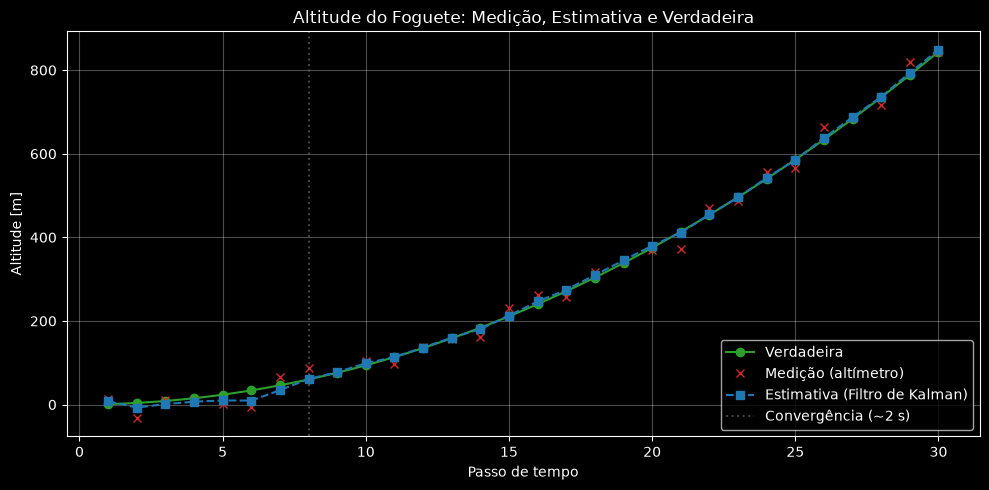

In [9]:
passos = np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(passos, alt_verdadeira, "o-", label="Verdadeira", color="tab:green")
ax.plot(passos, altimetro, "x", label="Medição (altímetro)", color="tab:red", markersize=6)
ax.plot(passos, alt_estimada, "s--", label="Estimativa (Filtro de Kalman)", color="tab:blue")
ax.axvline(x=8, color="gray", linestyle=":", alpha=0.5, label="Convergência (~2 s)")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Altitude [m]")
ax.set_title("Altitude do Foguete: Medição, Estimativa e Verdadeira")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Velocidade Estimada vs. Verdadeira

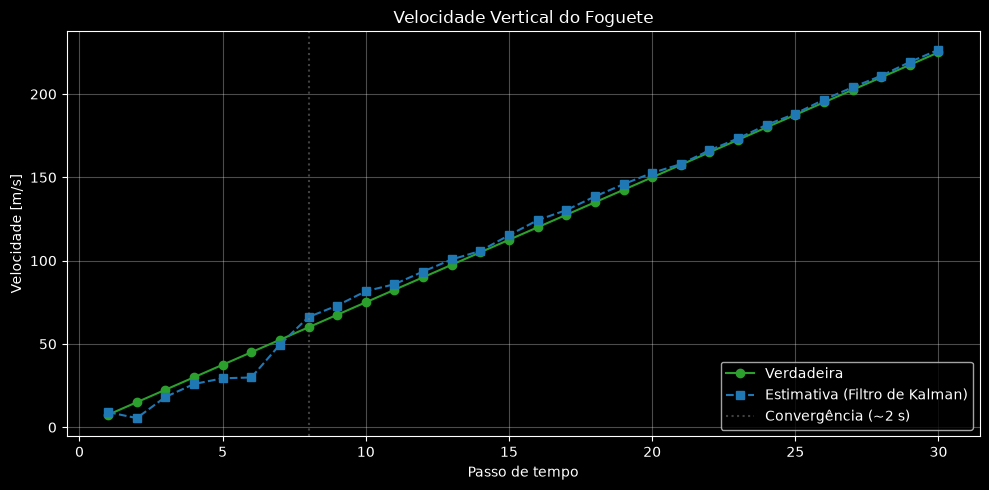

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(passos, vel_verdadeira, "o-", label="Verdadeira", color="tab:green")
ax.plot(passos, vel_estimada, "s--", label="Estimativa (Filtro de Kalman)", color="tab:blue")
ax.axvline(x=8, color="gray", linestyle=":", alpha=0.5, label="Convergência (~2 s)")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Velocidade [m/s]")
ax.set_title("Velocidade Vertical do Foguete")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Erro de Altitude ao Longo do Tempo

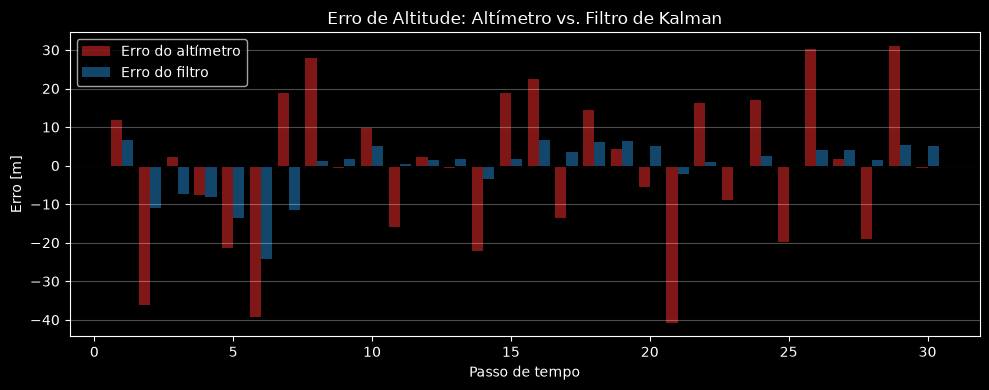

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(passos - 0.2, erro_alt_med, width=0.4, label="Erro do altímetro", color="tab:red", alpha=0.6)
ax.bar(passos + 0.2, erro_alt_est, width=0.4, label="Erro do filtro", color="tab:blue", alpha=0.6)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Erro [m]")
ax.set_title("Erro de Altitude: Altímetro vs. Filtro de Kalman")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 7.4 Evolução da Incerteza (Diagonal de $\mathbf{P}$)

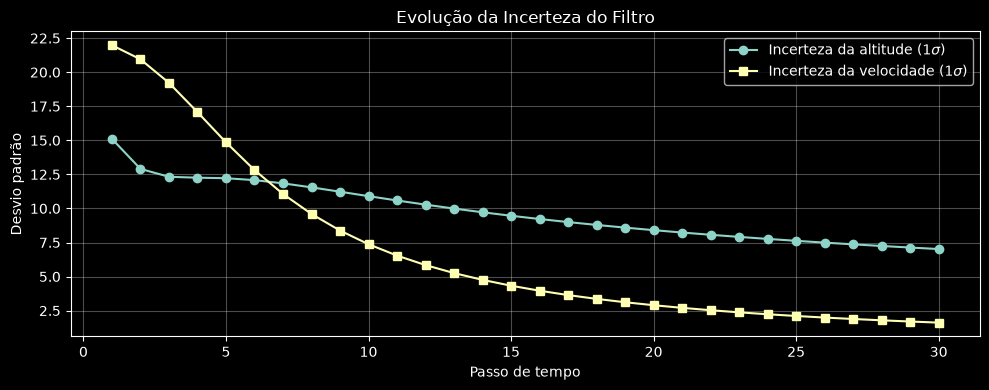

In [12]:
incerteza_alt = np.sqrt(historico_P[:, 0, 0])
incerteza_vel = np.sqrt(historico_P[:, 1, 1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(passos, incerteza_alt, "o-", label=r"Incerteza da altitude (1$\sigma$)")
ax.plot(passos, incerteza_vel, "s-", label=r"Incerteza da velocidade (1$\sigma$)")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Desvio padrão")
ax.set_title("Evolução da Incerteza do Filtro")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()